In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
match_records = pd.read_csv('../data/each_match_records.csv')
ball_records = pd.read_csv('../data/each_ball_records.csv')

# print("Missing Values in Match Records:")
# print(match_records.isnull().sum())

# print("\nMissing Values in Ball Records:")
# print(ball_records.isnull().sum())

# print("\nDuplicate Rows in Match Records:")
# print(match_records.duplicated().sum())

# print("\nDuplicate Rows in Ball Records:")
# print(ball_records.duplicated().sum())

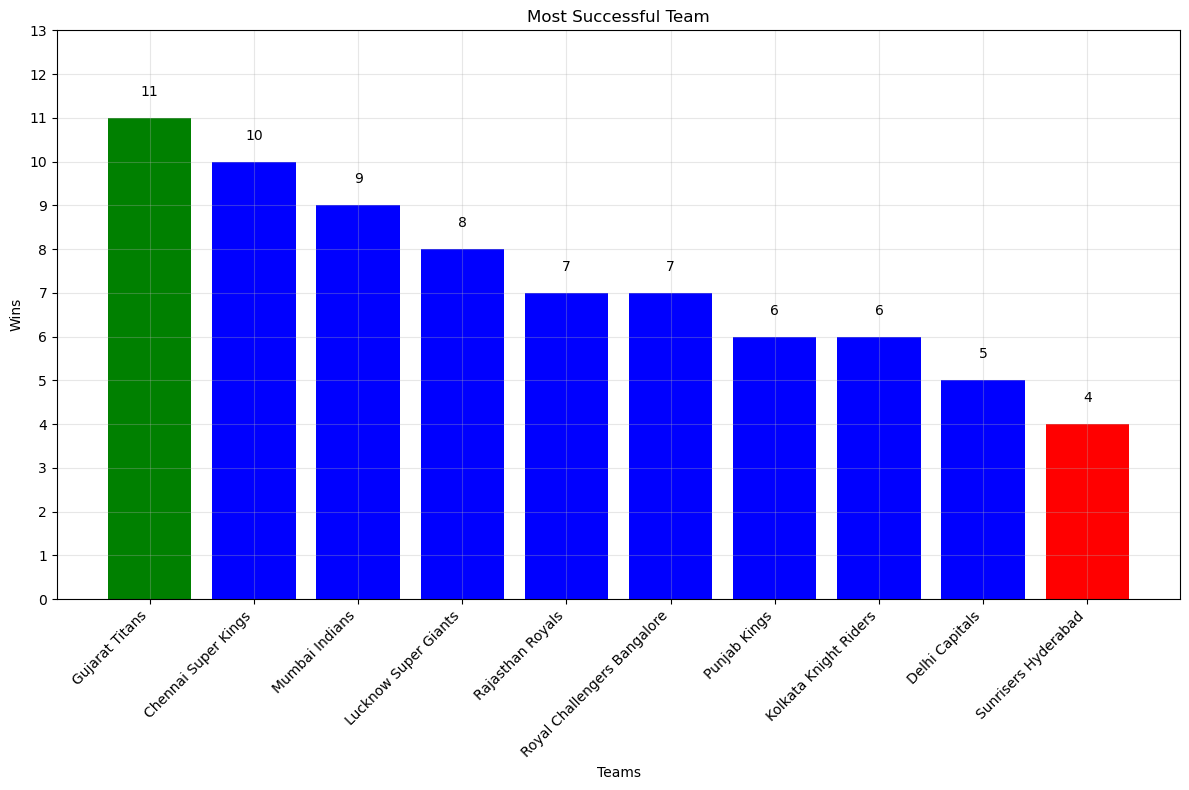


1. Most Successful Team
- Identifies the team with the highest number of match wins.
- Helps determine overall dominance in the dataset.



In [3]:
# Analysis 1
# Most Successful Team

#winner_count = match_records['winner'].value_counts()

winner_count = match_records['winner'].value_counts().drop('No Result')

plt.figure(figsize=(12, 8))

colors = [
    'green' if x == max(winner_count)
    else 'red' if x == min(winner_count)
    else 'blue'
    for x in winner_count
]

plt.bar(winner_count.index,winner_count, color=colors)
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.title("Most Successful Team")
plt.xticks(rotation=45, ha='right')
plt.yticks(range(0, max(winner_count) + 3, 1))
plt.grid(alpha=0.3)
plt.tight_layout()

for i in range(len(winner_count)):
    plt.text(winner_count.index[i],winner_count.iloc[i] + 0.5,
             str(winner_count.iloc[i]), ha='center')

plt.savefig("../images/most_successful_teams.png", bbox_inches="tight")
plt.show()
print("""
1. Most Successful Team
- Identifies the team with the highest number of match wins.
- Helps determine overall dominance in the dataset.
""")

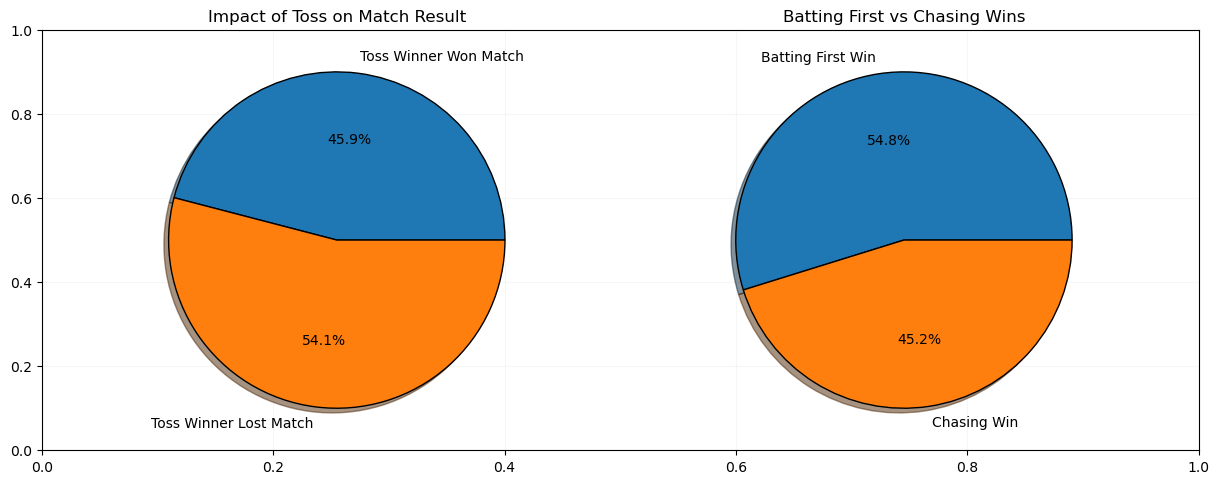


2(i). Impact of Toss on Match Result
- Compares matches won and lost by toss-winning teams.
- Evaluates the impact of winning the toss on match outcomes.

2(ii). Batting First vs Chasing
- Compares success rates of teams batting first and chasing.
- Helps understand match-winning strategies.



In [4]:
# Analysis 2
# Win by Batting First vs Chasing
# Impact of Toss on Match Result

# Impact of Toss on Match Result
toss_winner_match_winner = (
    match_records['toss_won'] == match_records['winner']
).sum()

toss_winner_lost = (
    match_records['toss_won'] != match_records['winner']
).sum()

plt.figure(figsize=(12,5))
plt.grid(alpha=0.1)

plt.subplot(1,2,1)

#color= ['green', 'red']
#explode = [0, 0.1]

plt.pie(
    [toss_winner_match_winner, toss_winner_lost],
    labels=['Toss Winner Won Match', 'Toss Winner Lost Match'],
    autopct='%1.1f%%',
    shadow=True,
    wedgeprops={"edgecolor":"black", "linewidth": 1, "linestyle":"-"}
)

plt.title('Impact of Toss on Match Result')

# Win by Batting First vs Chasing
batting_first_win = (match_records['winner_runs'] > 0).sum()
chasing_win = (match_records['winner_wickets'] > 0).sum()

plt.subplot(1,2,2)
plt.pie(
    [batting_first_win, chasing_win],
    labels=['Batting First Win', 'Chasing Win'],
    autopct='%1.1f%%',
    shadow=True,
    wedgeprops={"edgecolor":"black", "linewidth": 1, "linestyle":"-"}
)

plt.tight_layout()
plt.title('Batting First vs Chasing Wins')

plt.savefig("../images/toss_match_result_and_batting_first_vs_chasing.png", bbox_inches="tight")
plt.show()

print("""
2(i). Impact of Toss on Match Result
- Compares matches won and lost by toss-winning teams.
- Evaluates the impact of winning the toss on match outcomes.

2(ii). Batting First vs Chasing
- Compares success rates of teams batting first and chasing.
- Helps understand match-winning strategies.
""")

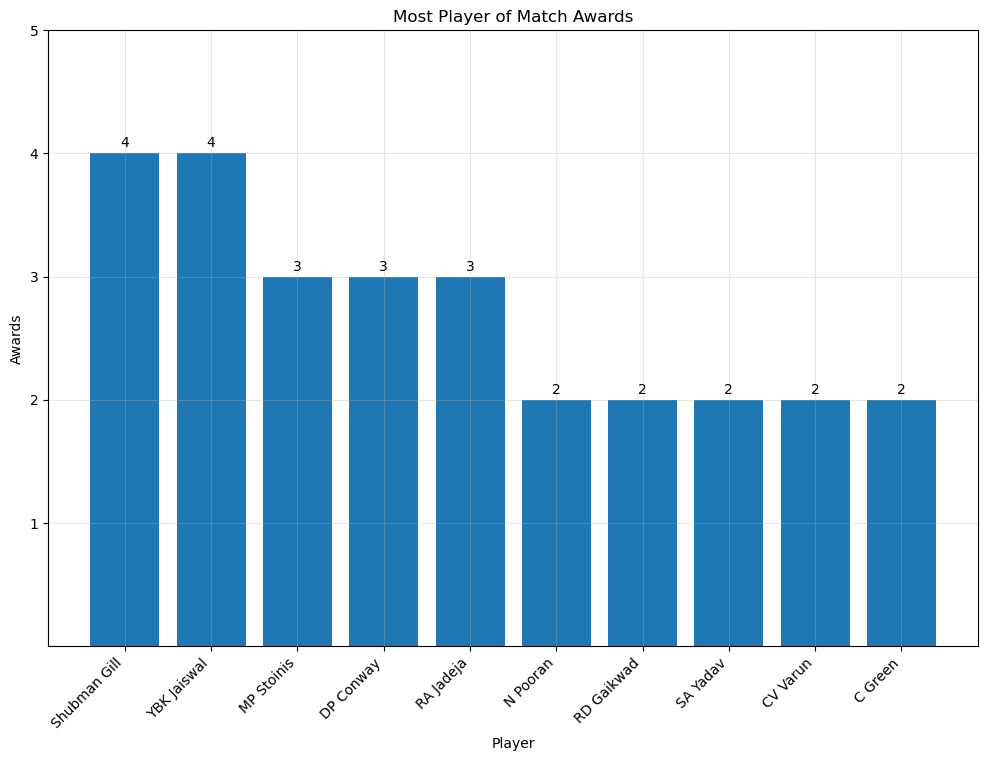


3. Player of the Match Awards
- Highlights the most impactful players.
- Frequent awards indicate consistent match-winning performances.



In [5]:
# Analysis 3
# Most Player of Match Awards

mom = match_records['man_of_match'].value_counts().head(10)

plt.figure(figsize=(12,8))

plt.bar(mom.index,mom)
plt.title("Most Player of Match Awards")
plt.xlabel("Player")
plt.ylabel("Awards")
plt.yticks(range(1, max(mom) + 2)) # remove float form y axis 
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)

for i in range(len(mom)):
    plt.text(mom.index[i],mom.iloc[i]+0.05,mom.iloc[i],ha='center')

plt.savefig("../images/player_of_match_awards.png", bbox_inches="tight")
plt.show()

print("""
3. Player of the Match Awards
- Highlights the most impactful players.
- Frequent awards indicate consistent match-winning performances.
""")

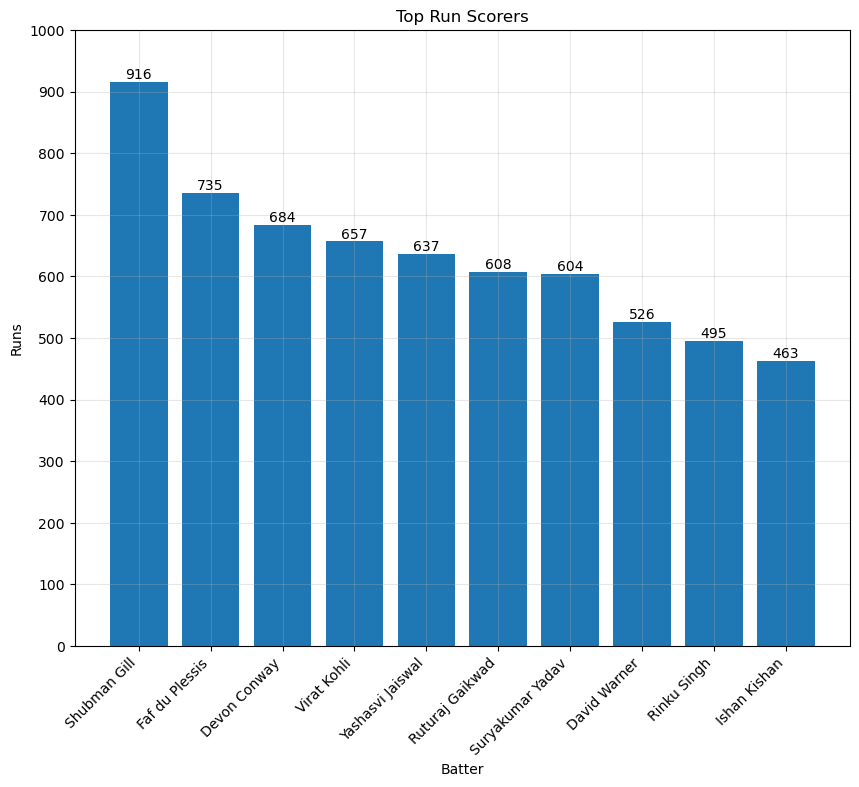


4. Top Run Scorers
- Identifies the highest run scorers across all matches.
- Reveals batting consistency.



In [6]:
# Analysis 4
# Top Run Scorers

batter_runs = ball_records.groupby('batter')['score'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,8))

plt.bar(batter_runs.index, batter_runs)

plt.title("Top Run Scorers")
plt.xlabel("Batter")
plt.ylabel("Runs")
plt.xticks(rotation=45,ha='right')
plt.yticks(range(0,max(batter_runs)+100,100))
plt.grid(alpha=0.3)

for i in range(len(batter_runs)):
    plt.text(batter_runs.index[i],batter_runs.iloc[i] + 5,str(batter_runs.iloc[i]),ha='center')

plt.savefig("../images/top_run_scorers.png", bbox_inches="tight")
plt.show()

print("""
4. Top Run Scorers
- Identifies the highest run scorers across all matches.
- Reveals batting consistency.
""")

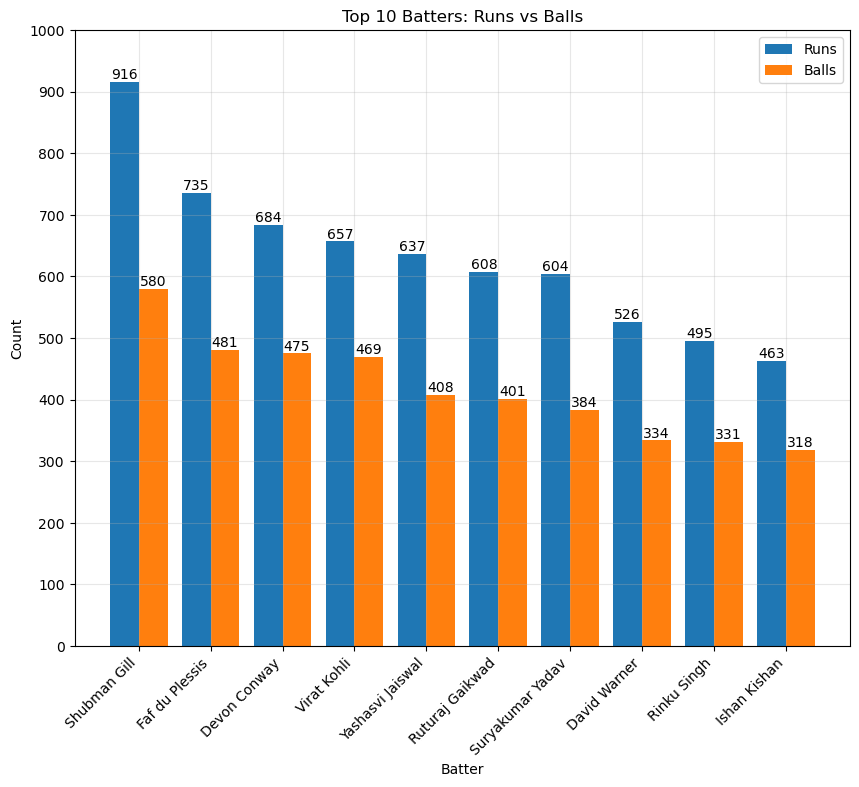


5. Runs vs Balls Faced
- Compares runs scored with balls played.
- Helps evaluate scoring efficiency.



In [7]:
# Analysis 5
# Top Run Scorers : Runs vs Balls

batter_runs = ball_records.groupby('batter')['score'].sum().sort_values(ascending=False).head(10)
batter_balls = ball_records['batter'].value_counts().head(10)

plt.figure(figsize=(10,8))

x= np.arange(len(batter_runs))
width = 0.4

plt.bar(x - width/2, batter_runs, width, label='Runs')
plt.bar(x + width/2, batter_balls, width, label='Balls')

plt.title("Top 10 Batters: Runs vs Balls")
plt.xlabel("Batter")
plt.ylabel("Count")
plt.xticks(x, batter_runs.index, rotation=45,ha='right')
plt.yticks(range(0,max(batter_runs)+100,100))
plt.legend()
plt.grid(alpha=0.3)

for i in range(len(batter_runs)):
    plt.text(x[i] - width/2,batter_runs.iloc[i] + 5,str(batter_runs.iloc[i]),ha='center')
    plt.text(x[i] + width/2,batter_balls.iloc[i] + 5,str(batter_balls.iloc[i]),ha='center')

plt.savefig("../images/runs_vs_balls_faced.png", bbox_inches="tight")
plt.show()
print("""
5. Runs vs Balls Faced
- Compares runs scored with balls played.
- Helps evaluate scoring efficiency.
""")

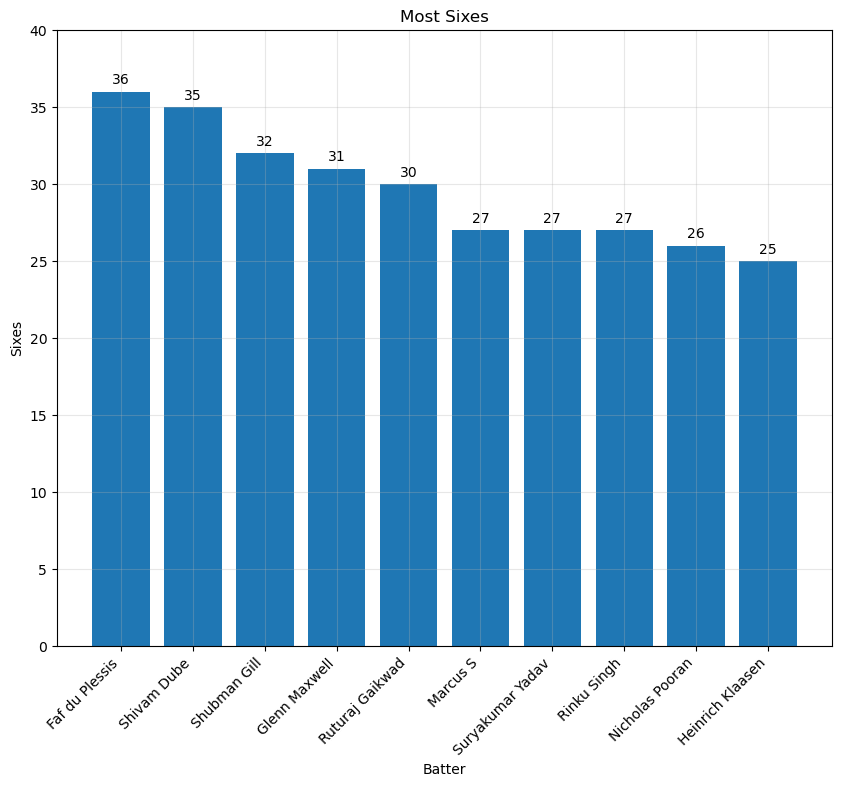


6. Most Sixes
- Shows the most aggressive batters.
- Indicates power-hitting ability.



In [8]:
# Analysis 6
# Most Sixes

six = ball_records[ball_records['score'] == 6]

sixes = six.groupby('batter')['score'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,8))
plt.bar(sixes.index,sixes)

plt.title("Most Sixes")
plt.xlabel("Batter")
plt.ylabel("Sixes")
plt.yticks(range(0,max(sixes) + 5, 5))
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)

for i in range(len(sixes)):
    plt.text(sixes.index[i],sixes.iloc[i] + 0.5,str(sixes.iloc[i]), ha='center')

plt.savefig("../images/most_sixes.png", bbox_inches="tight")
plt.show()

print("""
6. Most Sixes
- Shows the most aggressive batters.
- Indicates power-hitting ability.
""")

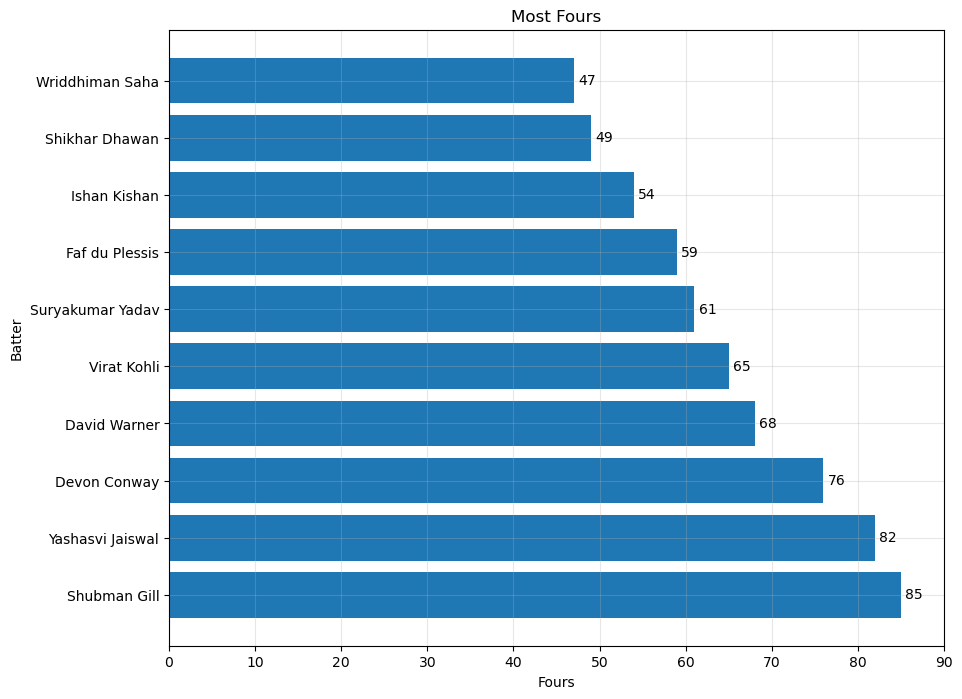


7. Most Fours
- Identifies players who rely heavily on boundary scoring.
- Measures batting dominance through placement and timing.



In [9]:
# Analysis 7
# Most Fours

four = ball_records[ball_records['score'] == 4]

fours = four.groupby('batter')['score'].size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,8))
plt.barh(fours.index,fours)

plt.title("Most Fours")
plt.xlabel("Fours")
plt.ylabel("Batter")

plt.xticks(range(0,max(fours)+10, 10))
plt.grid(alpha=0.3)

for i in range(len(fours)):
    plt.text(fours.iloc[i] + 0.5, fours.index[i],str(fours.iloc[i]), va='center')

plt.savefig("../images/most_fours.png", bbox_inches="tight")
plt.show()

print("""
7. Most Fours
- Identifies players who rely heavily on boundary scoring.
- Measures batting dominance through placement and timing.
""")

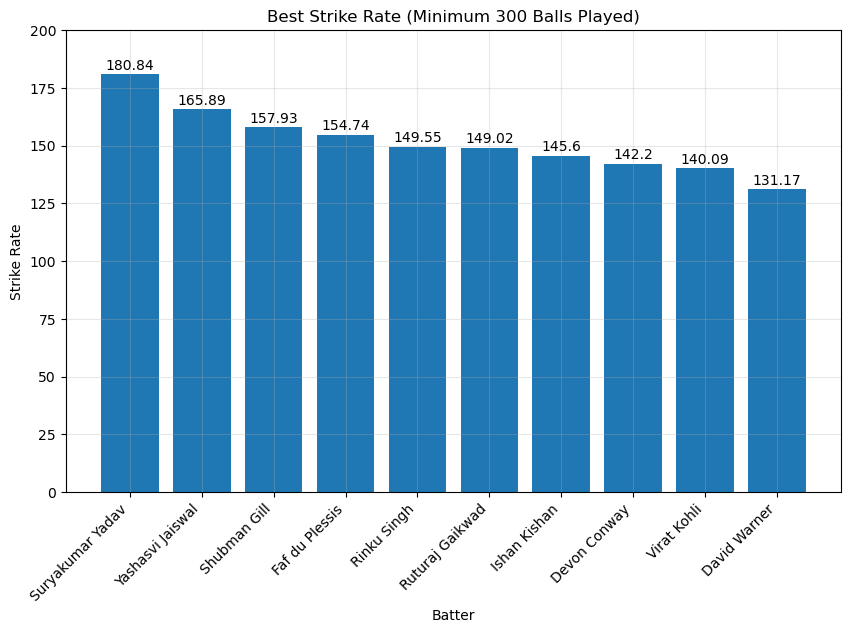


8. Best Strike Rate
- Considers players with a minimum of 300 balls faced.
- Highlights efficient run scorers.



In [10]:
# Analysis 8
# Best Strike Rate (Minimum 300 Balls Played)

balls = ball_records['batter'].value_counts()
runs = ball_records.groupby('batter')['score'].sum()

qualified_batters = balls[balls >= 300]
strike_rate = (runs / balls) * 100
strike_rate = strike_rate.loc[qualified_batters.index]
best_strike_rate = strike_rate.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(best_strike_rate.index,best_strike_rate)

plt.title("Best Strike Rate (Minimum 300 Balls Played)")
plt.xlabel("Batter")
plt.ylabel("Strike Rate")

plt.xticks(rotation=45, ha='right')
plt.yticks(range(0,int(max(best_strike_rate))+25,25))
plt.grid(alpha=0.3)

for i in range(len(best_strike_rate)):
    plt.text(best_strike_rate.index[i],best_strike_rate.iloc[i] + 2,
             round(best_strike_rate.iloc[i],2), ha='center')

plt.savefig("../images/best_strike_rate.png", bbox_inches="tight")
plt.show()

print("""
8. Best Strike Rate
- Considers players with a minimum of 300 balls faced.
- Highlights efficient run scorers.
""")

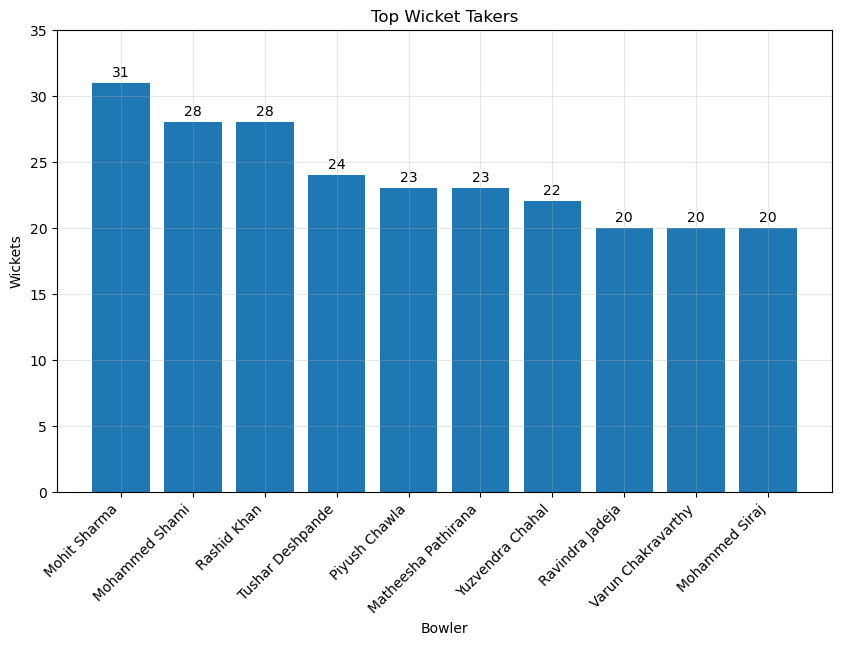


9. Top Wicket Takers
- Identifies bowlers who take the most wickets.
- Measures bowling effectiveness.



In [11]:
# Analysis 9
# Top Wicket Takers

wickets = ball_records[ball_records['outcome'] == 'w']

bowler = wickets['bowler'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(bowler.index,bowler)

plt.title("Top Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=45,ha='right')
plt.yticks(range(0,max(bowler)+5, 5))
plt.grid(alpha=0.3)

for i in range(len(bowler)):
    plt.text(bowler.index[i],bowler.iloc[i]+0.5,
             bowler.iloc[i],ha='center')

plt.savefig("../images/top_wicket_takers.png", bbox_inches="tight")
plt.show()

print("""
9. Top Wicket Takers
- Identifies bowlers who take the most wickets.
- Measures bowling effectiveness.
""")

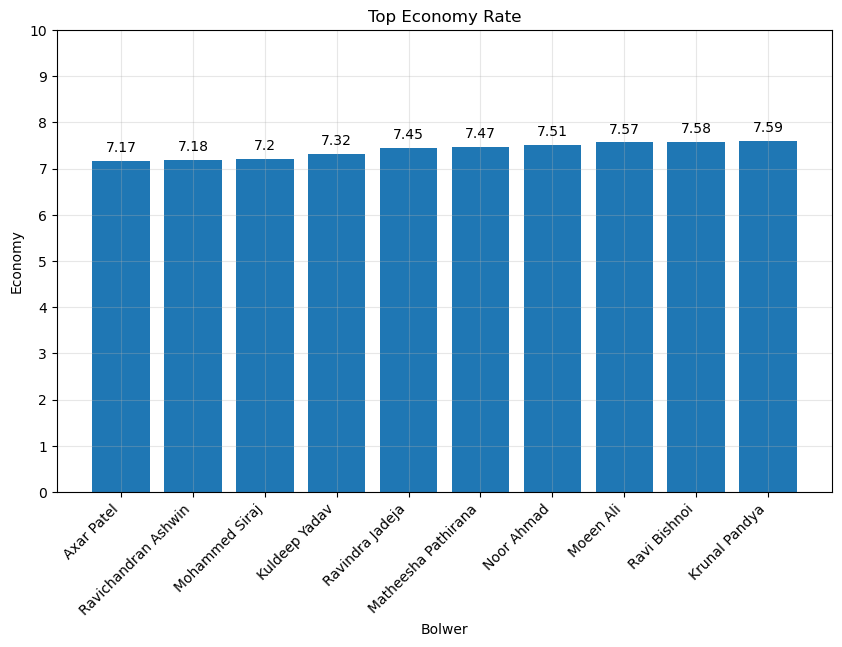


10. Economy Rate
- Shows bowlers who concede fewer runs per over.
- Useful for evaluating control and consistency.



In [12]:
# Analysis 10
# Economy Rate

ball = ball_records.groupby('bowler').size()
runs_given = ball_records.groupby('bowler')['score'].sum()

ball = ball[ball >100]
economy = (runs_given/(ball/6)).sort_values().head(10)

plt.figure(figsize=(10,6))
plt.bar(economy.index,economy)

plt.title("Top Economy Rate")
plt.xlabel("Bolwer")
plt.ylabel("Economy")

plt.xticks(rotation=45,ha='right')
plt.yticks(range(0, int(max(economy)) + 4, 1))

plt.grid(alpha=0.3)
for i in range(len(economy)):
    plt.text(economy.index[i],economy.iloc[i]+0.2,round((economy.iloc[i]),2),ha='center')

plt.savefig("../images/best_economy_rate.png", bbox_inches="tight")
plt.show()
print("""
10. Economy Rate
- Shows bowlers who concede fewer runs per over.
- Useful for evaluating control and consistency.
""")

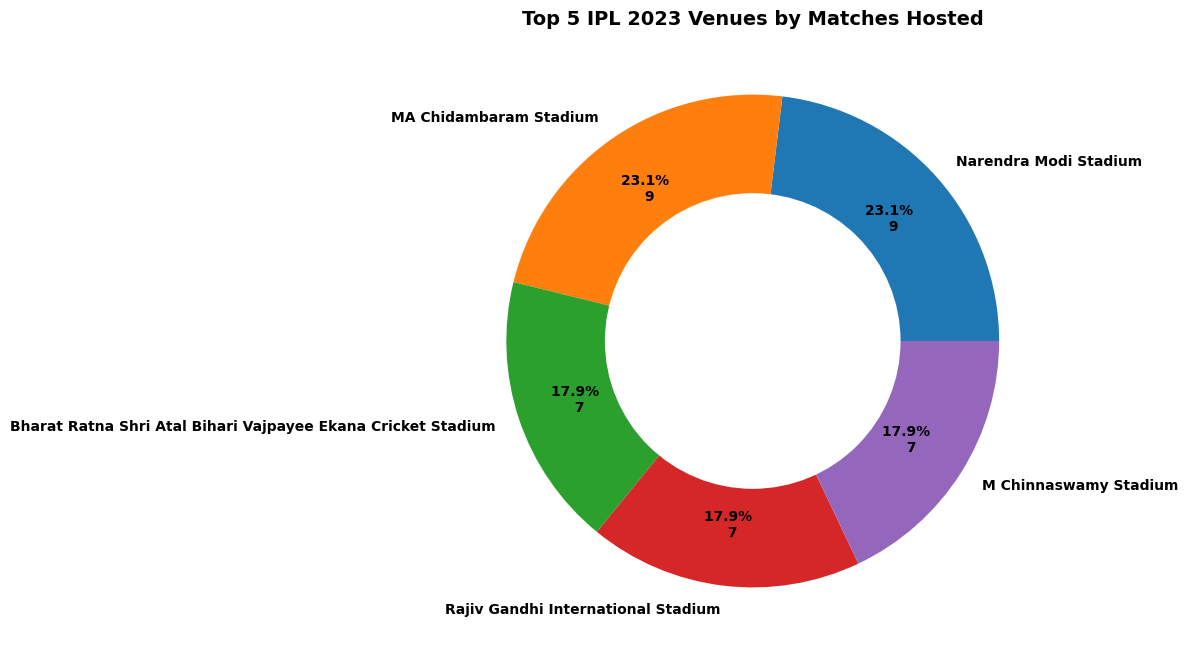


11. Venue Analysis
- Reveals venues hosting the highest number of matches.
- Helps understand venue usage patterns.



In [13]:
# Analysis 11
# Venue Analysis

venue = match_records['venue'].value_counts().head()

def percentage_count(pc):
    count = int(round(pc * sum(venue) / 100))
    return f"{pc:.1f}% \n {count}"

plt.figure(figsize=(8,8))
plt.pie(venue,
        labels=venue.index,
        autopct=percentage_count,
        pctdistance=0.75,    # percentage/count aur anda
        textprops={
            'fontsize':10,
            'fontweight':'bold'
        }
       )

plt.title(
    "Top 5 IPL 2023 Venues by Matches Hosted",
    fontsize=14,
    fontweight='bold'
)

centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.savefig("../images/venue_analysis.png", bbox_inches="tight")
plt.show()

print("""
11. Venue Analysis
- Reveals venues hosting the highest number of matches.
- Helps understand venue usage patterns.
""")

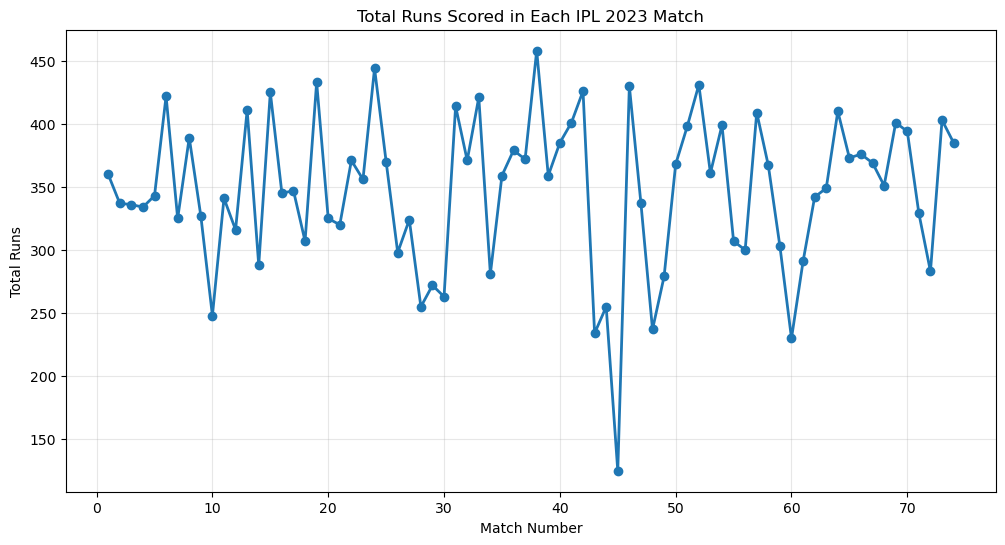


12. Total Runs per Match
- Shows scoring trends across matches.
- Helps identify high-scoring and low-scoring games.



In [14]:
# Analysis 12
# Total Runs Scored Match-by-Match

tot_runs = ball_records.groupby('match_no')['score'].sum()

plt.figure(figsize=(12,6))
plt.plot(tot_runs.index,tot_runs, "o-", linewidth=2 )

plt.title('Total Runs Scored in Each IPL 2023 Match')
plt.xlabel('Match Number')
plt.ylabel('Total Runs')

plt.grid(alpha=0.3)
plt.savefig("../images/total_runs_per_match.png", bbox_inches="tight")
plt.show()

print("""
12. Total Runs per Match
- Shows scoring trends across matches.
- Helps identify high-scoring and low-scoring games.
""")